# Healthcare Data Cleaning & Exploratory Data Analysis

#### Problem Statement: A multi-specialty hospital chain is facing issues with inconsistent patient records, incorrect medical information, duplicate entries, missing values, and unstructured hospital billing data.

#### Business Objective: 
#### -Improve healthcare data quality
#### -Reduce inconsistencies in patient records
#### -Understand hospital admission behavior
#### -Analyze billing and treatment patterns
#### -Support management decision-making using data insights

### Import Required Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [84]:
df = pd.read_csv(r'hospital_data_unclean.csv')
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,NaN,30.0,M,B-,CANCER,2024.01.31,Matthew Smith ##,"Sons and Miller,,",Blue Cross,18856.281305978155 USD,328.0,Urgent,2/2/2024,Paracetamol,N
1,LEsliE tErrY,62.0,M,A+,OBESITY,2019.08.20,Samantha Davies ##,"Kim Inc,,",Medicare,33643.327286577885 USD,265.0,Emergency,26-08-2019,Ibuprofen,unknown
2,dAnnY SMiTH,76.0,FEMALE,A-,OBESITY,9/22/2022,NaN,"Cook PLC,,",Aetna,27955.096078842456 USD,205.0,Emergency,7/10/2022,Aspirin,N
3,NaN,28.0,FEMALE,O+,DIABETES,11/18/2020,Kevin Wells ##,"Hernandez Rogers and Vang,,,",Medicare,37909.78240987528 USD,450.0,Elective,2020.12.18,Ibuprofen,abn
4,ADRIeNNe bELL,43.0,FEMALE,AB+-,CANCER,2022.09.19,Kathleen Hanna ##,NaN,Blue Cross,14238.317813937623 USD,458.0,Urgent,10/9/2022,Penicillin,abn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55500,cASsanDRA cArNEy,32.0,M,B+,HYPERTENSION,2/21/2022,Cassandra Montoya ##,"Walls-Castillo,,",NaN,19601.381722682367 USD,420.0,Emergency,9/3/2022,Ibuprofen,unknown
55501,Dr. dAViD SmITh,18.0,M,A+,HYPERTENSION,23-10-2019,Eric Martinez ##,"and Byrd Carroll, Washington,,",Blue Cross,6459.616670892389 USD,357.0,Urgent,20-11-2019,Paracetamol,unknown
55502,liSA aLlen,65.0,M,O--,OBESITY,20-12-2019,Daryl Mckinney ##,"Austin, Morgan and Ellis,,",NaN,36639.9788574008 USD,136.0,Elective,2020.01.05,Aspirin,abn
55503,AAron craig,22.0,FEMALE,O-+,ARTHRITIS,2024.03.21,Justin Wolfe ##,NaN,Medicare,13007.88736491442 USD,448.0,Elective,4/19/2024,Ibuprofen,unknown


### Basic Data Understanding

In [85]:
df.shape

(55505, 15)

In [86]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

##### Dataset Information - This helps identify: incorrect datatypes, null values, numeric vs object columns

In [87]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 55505 entries, 0 to 55504
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                51065 non-null  str    
 1   Age                 51065 non-null  float64
 2   Gender              51065 non-null  str    
 3   Blood Type          51065 non-null  str    
 4   Medical Condition   51102 non-null  str    
 5   Date of Admission   51065 non-null  str    
 6   Doctor              51065 non-null  str    
 7   Hospital            51064 non-null  str    
 8   Insurance Provider  51294 non-null  str    
 9   Billing Amount      51101 non-null  str    
 10  Room Number         51064 non-null  float64
 11  Admission Type      51065 non-null  str    
 12  Discharge Date      51064 non-null  str    
 13  Medication          51065 non-null  str    
 14  Test Results        51065 non-null  str    
dtypes: float64(2), str(13)
memory usage: 6.4 MB


##### We can see date is not in date format and billing amount is also in string format

##### Statistical Summary - To identify: unusual values, outliers, age distribution, billing amount patterns

In [88]:
df.describe()

,Age,Room Number
count,51065.000000,51064.000000
mean,51.576207,301.074554
std,19.591399,115.264773
min,13.000000,101.000000
25%,35.000000,202.000000
50%,52.000000,302.000000
75%,68.000000,400.000000
max,89.000000,500.000000


### Check Missing Values

In [89]:
df.isnull().sum()

Name                  4440
Age                   4440
Gender                4440
Blood Type            4440
Medical Condition     4403
Date of Admission     4440
Doctor                4440
Hospital              4441
Insurance Provider    4211
Billing Amount        4404
Room Number           4441
Admission Type        4440
Discharge Date        4441
Medication            4440
Test Results          4440
dtype: int64

##### Missing values can: reduce analysis accuracy, affect dashboards, create wrong business insights

### Handle Missing Values

In [90]:
missing_percentage = (df.isnull().sum() / len(df)) * 100 # calculate missing percentage
print(missing_percentage)

Name                  7.999279
Age                   7.999279
Gender                7.999279
Blood Type            7.999279
Medical Condition     7.932619
Date of Admission     7.999279
Doctor                7.999279
Hospital              8.001081
Insurance Provider    7.586704
Billing Amount        7.934420
Room Number           8.001081
Admission Type        7.999279
Discharge Date        8.001081
Medication            7.999279
Test Results          7.999279
dtype: float64


In [91]:
df['Age'] = df['Age'].fillna(df['Age'].median())

##### Why Median? - Median handles outliers better

In [92]:
df['Room Number'] = df['Room Number'].fillna(df['Room Number'].median())

In [93]:
categorical_cols = df.select_dtypes(exclude='number').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

##### Why Mode? - For categorical Mode fills the most frequent category

In [94]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [95]:
df.describe()

,Age,Room Number
count,55505.000000,55505.000000
mean,51.610107,301.148599
std,18.791821,110.557635
min,13.000000,101.000000
25%,36.000000,210.000000
50%,52.000000,302.000000
75%,67.000000,392.000000
max,89.000000,500.000000


### Check Duplicate Records

In [96]:
df.duplicated().sum()

np.int64(5)

##### Duplicate data can: increase reporting errors, affect KPI calculations, create inaccurate business insights

### Remove Duplicates

In [97]:
df = df.drop_duplicates()

In [98]:
df.duplicated().sum()

np.int64(0)

### Check Incorrect Datatypes

In [99]:
df.dtypes

Name                      str
Age                   float64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount            str
Room Number           float64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

##### Incorrect datatypes can: break calculations, create visualization issues, affect analysis accuracy

### Convert Age and Room Number Column

In [100]:
df['Age'] = df['Age'].round().astype(int)

In [101]:
df['Room Number'] = df['Room Number'].astype(int)

### Convert Date Columns

In [102]:
df['Date of Admission'].unique()

<StringArray>
['2024.01.31', '2019.08.20',  '9/22/2022', '11/18/2020', '2022.09.19',
 '2023.12.20',  '11/3/2020', '2021.12.28',   '1/7/2020', '2021.05.23',
 ...
 '17-08-2020', '20-01-2024', '2021.01.05', '2022.04.17',  '2/21/2022',
 '11/24/2020',  '5/18/2019', '2020.05.31', '2022.08.14', '2021.02.06']
Length: 4820, dtype: str

In [103]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce', format='mixed')

In [104]:
df['Date of Admission'].isnull().sum()

np.int64(0)

In [111]:
df['Date of Admission'].unique()

<DatetimeArray>
['2024-01-31 00:00:00', '2019-08-20 00:00:00', '2022-09-22 00:00:00',
 '2020-11-18 00:00:00', '2022-09-19 00:00:00', '2023-12-20 00:00:00',
 '2020-11-03 00:00:00', '2021-12-28 00:00:00', '2020-01-07 00:00:00',
 '2021-05-23 00:00:00',
 ...
 '2023-02-27 00:00:00', '2019-01-06 00:00:00', '2022-02-18 00:00:00',
 '2023-11-05 00:00:00', '2024-11-04 00:00:00', '2019-05-31 00:00:00',
 '2021-02-06 00:00:00', '2021-03-14 00:00:00', '2019-02-11 00:00:00',
 '2024-12-01 00:00:00']
Length: 1887, dtype: datetime64[us]

In [105]:
df['Discharge Date'].unique()

<StringArray>
[  '2/2/2024', '26-08-2019',  '7/10/2022', '2020.12.18',  '10/9/2022',
 '2023.12.24', '15-11-2020',   '1/7/2022',  '7/14/2020', '22-06-2021',
 ...
 '2019.05.18', '14-05-2019', '2024.06.04', '26-12-2021',  '5/15/2019',
 '26-05-2024',  '5/24/2019', '2024.06.03', '23-05-2024', '2019.05.19']
Length: 4894, dtype: str

In [106]:
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce', format='mixed')

In [107]:
df['Discharge Date'].isnull().sum()

np.int64(0)

In [110]:
df['Discharge Date'].unique()

<DatetimeArray>
['2024-02-02 00:00:00', '2019-08-26 00:00:00', '2022-07-10 00:00:00',
 '2020-12-18 00:00:00', '2022-10-09 00:00:00', '2023-12-24 00:00:00',
 '2020-11-15 00:00:00', '2022-01-07 00:00:00', '2020-07-14 00:00:00',
 '2021-06-22 00:00:00',
 ...
 '2024-03-07 00:00:00', '2019-01-12 00:00:00', '2024-08-01 00:00:00',
 '2024-10-04 00:00:00', '2024-10-03 00:00:00', '2019-04-07 00:00:00',
 '2024-05-31 00:00:00', '2019-03-06 00:00:00', '2024-06-06 00:00:00',
 '2019-01-06 00:00:00']
Length: 1917, dtype: datetime64[us]

In [108]:
df.dtypes

Name                             str
Age                            int64
Gender                           str
Blood Type                       str
Medical Condition                str
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider               str
Billing Amount                   str
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
dtype: object

##### Datetime conversion helps in: monthly analysis, yearly trends, hospital admission patterns, time-based reporting

### Check Formatting Issues

In [109]:
df.select_dtypes(exclude='number').columns

Index(['Name', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Admission Type', 'Discharge Date', 'Medication',
       'Test Results'],
      dtype='str')

In [112]:
categorical_cols = ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 
                    'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication', 'Test Results']

In [113]:
for col in categorical_cols:
    print(df[col].value_counts(),'\n')

Name
AAron craig          4441
daVID BROwn             2
joHn BElL               2
JILl eatON              2
RYaN JOHNSon            2
                     ... 
elizAbETH JACksoN       1
KylE PerEZ              1
HeaTHer Wang            1
JeNNIfer JoNeS          1
jAMEs gArCia            1
Name: count, Length: 51050, dtype: int64 

Gender
M         30042
FEMALE    25458
Name: count, dtype: int64 

Blood Type
A-      6110
O+      1650
B-      1644
O-      1639
A+      1637
AB-     1627
B-+     1620
AB+-    1619
AB-+    1618
A+-     1618
B+-     1613
AB+     1613
B-      1605
A-      1603
B+      1596
B++     1588
A--     1586
AB++    1582
B+      1581
O++     1579
A+      1575
A++     1572
AB+     1571
A-+     1569
B--     1569
AB-     1567
AB--    1565
O--     1564
O+-     1562
O+      1557
O-+     1555
O-      1546
Name: count, dtype: int64 

Medical Condition
DIABETES        13015
ARTHRITIS        8596
HYPERTENSION     8504
OBESITY          8496
ASTHMA           8459
CANCER          

### Check Extra Spaces

In [114]:
for col in categorical_cols:
    space_count = df[col].astype(str).str.contains(' ').sum()
    print(col, ':', space_count)

Name : 55500
Gender : 0
Blood Type : 17381
Medical Condition : 0
Doctor : 55500
Hospital : 38653
Insurance Provider : 10226
Billing Amount : 55464
Admission Type : 0
Medication : 0
Test Results : 0


### Remove Extra Spaces

In [116]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

##### Extra spaces create: duplicate categories, incorrect grouping, inaccurate analysis

### Standardize Columns

##### Convert the 'Name' and 'Medical Condition' column to Proper text format

In [118]:
df['Name'] = df['Name'].astype(str).str.title()

In [119]:
df['Medical Condition'] = df['Medical Condition'].astype(str).str.title()

##### Check Unique Values First

In [120]:
print(df['Gender'].unique())
print(df['Insurance Provider'].unique())
print(df['Admission Type'].unique())
print(df['Medication'].unique())
print(df['Test Results'].unique())

<StringArray>
['M', 'FEMALE']
Length: 2, dtype: str
<StringArray>
['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna']
Length: 5, dtype: str
<StringArray>
['Urgent', 'Emergency', 'Elective']
Length: 3, dtype: str
<StringArray>
['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor']
Length: 5, dtype: str
<StringArray>
['N', 'unknown', 'abn']
Length: 3, dtype: str


##### We need to standardize the gender and test result data

In [121]:
df['Gender'] = df['Gender'].replace({'M':'Male', 'FEMALE':'Female'})

In [122]:
df['Test Results'] = df['Test Results'].replace({'N':'Normal', 'unknown':'Unknown', 'abn':'Abnormal'})

##### Standardization improves: reporting consistency, dashboard accuracy, grouping and filtering

### Clean Special Characters

In [126]:
df['Doctor'] = df['Doctor'].astype(str).str.replace('#','').str.strip()
df['Doctor']

0          Matthew Smith
1        Samantha Davies
2          Michael Smith
3            Kevin Wells
4         Kathleen Hanna
              ...       
55495      Joshua Jarvis
55496    Taylor Sullivan
55497     Joe Jacobs DVM
55498     Kimberly Curry
55499      Dennis Warren
Name: Doctor, Length: 55500, dtype: str

In [125]:
df['Hospital'] = df['Hospital'].astype(str).str.replace(',','').str.strip()
df['Hospital']

0                    Sons and Miller
1                            Kim Inc
2                           Cook PLC
3          Hernandez Rogers and Vang
4                          LLC Smith
                    ...             
55495                 Jones-Thompson
55496                   Tucker-Moyer
55497    and Mahoney Johnson Vasquez
55498        Jackson Todd and Castro
55499                 Henry Sons and
Name: Hospital, Length: 55500, dtype: str

##### Special characters: reduce readability, create matching problems, affect dashboard filters

### Clean Billing Amount Column

##### Remove USD Text

In [127]:
df['Billing Amount'] = (df['Billing Amount'].str.replace('USD','')).str.strip()

##### Convert Billing Amount to Numeric

In [128]:
df['Billing Amount'] = (pd.to_numeric(df['Billing Amount'],errors='coerce')).round(2)

In [129]:
df['Billing Amount']

0        18856.28
1        33643.33
2        27955.10
3        37909.78
4        14238.32
           ...   
55495     2650.71
55496    31457.80
55497    27620.76
55498    32451.09
55499     4010.13
Name: Billing Amount, Length: 55500, dtype: float64

##### Numeric Conversion required for: average billing analysis, revenue analysis, KPI calculations, charts and dashboards

### Clean Blood Type Column

In [130]:
df['Blood Type'] = (df['Blood Type'].str.replace({'++':'+', '+-':'+', '--':'-', '-+':'-'})).str.strip()

In [132]:
df['Blood Type'].unique()

<StringArray>
['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']
Length: 8, dtype: str

### Final Check

In [133]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Aaron Craig,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Unknown
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Michael Smith,Cook PLC,Aetna,27955.10,205,Emergency,2022-07-10,Aspirin,Normal
3,Aaron Craig,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,LLC Smith,Blue Cross,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.71,417,Elective,2020-09-15,Penicillin,Abnormal
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.80,316,Elective,2020-01-02,Lipitor,Normal
55497,Heather Wang,38,Female,B+,Diabetes,2020-07-13,Joe Jacobs DVM,and Mahoney Johnson Vasquez,UnitedHealthcare,27620.76,347,Urgent,2020-10-08,Ibuprofen,Abnormal
55498,Jennifer Jones,43,Male,O-,Arthritis,2020-03-04,Kimberly Curry,Jackson Todd and Castro,Medicare,32451.09,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [134]:
df.isnull().sum().sum()

np.int64(0)

In [135]:
df.duplicated().sum()

np.int64(54)

In [136]:
df = df.drop_duplicates() # Removing Duplicates
df.duplicated().sum()

np.int64(0)

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 55446 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55446 non-null  str           
 1   Age                 55446 non-null  int64         
 2   Gender              55446 non-null  str           
 3   Blood Type          55446 non-null  str           
 4   Medical Condition   55446 non-null  str           
 5   Date of Admission   55446 non-null  datetime64[us]
 6   Doctor              55446 non-null  str           
 7   Hospital            55446 non-null  str           
 8   Insurance Provider  55446 non-null  str           
 9   Billing Amount      55446 non-null  float64       
 10  Room Number         55446 non-null  int64         
 11  Admission Type      55446 non-null  str           
 12  Discharge Date      55446 non-null  datetime64[us]
 13  Medication          55446 non-null  str           
 14  Test R

In [139]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55446.000000,55446,55446.000000,55446.000000,55446
mean,51.608953,2021-09-12 20:10:21.750892,26446.206694,301.151246,2021-09-05 09:48:03.973595
min,13.000000,2019-01-06 00:00:00,-58705.400000,101.000000,2019-01-06 00:00:00
25%,36.000000,2020-04-03 00:00:00,14292.182500,210.000000,2020-04-20 00:00:00
50%,52.000000,2021-08-07 00:00:00,27737.420000,302.000000,2021-08-25 00:00:00
75%,67.000000,2022-12-25 00:00:00,36699.962500,392.000000,2023-01-09 00:00:00
max,89.000000,2024-12-04 00:00:00,195715.760000,500.000000,2024-12-05 00:00:00
std,18.791821,NaN,14188.306261,110.534060,NaN


In [140]:
for col in df.columns:
    print(df[col].value_counts(),'\n')

Name
Aaron Craig         4440
Michael Williams      23
Robert Smith          22
Michael Smith         20
James Brown           18
                    ... 
Daniel Kemp            1
Erin Pineda            1
Whitney Ramirez        1
Deborah Pearson        1
Gloria Bowen           1
Name: count, Length: 37683, dtype: int64 

Age
52    5190
38     823
57     821
37     811
80     802
      ... 
16      20
88      19
14      15
13      14
89       5
Name: count, Length: 77, dtype: int64 

Gender
Male      30014
Female    25432
Name: count, dtype: int64 

Blood Type
A-     10860
B-      6430
A+      6399
AB+     6377
B+      6373
AB-     6370
O+      6342
O-      6295
Name: count, dtype: int64 

Medical Condition
Diabetes        13003
Arthritis        8584
Hypertension     8498
Obesity          8488
Asthma           8450
Cancer           8423
Name: count, dtype: int64 

Date of Admission
2020-03-04    4480
2019-11-07      49
2022-05-06      48
2023-02-04      48
2022-07-24      47
           

### Outlier Detection

In [141]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55446.000000,55446,55446.000000,55446.000000,55446
mean,51.608953,2021-09-12 20:10:21.750892,26446.206694,301.151246,2021-09-05 09:48:03.973595
min,13.000000,2019-01-06 00:00:00,-58705.400000,101.000000,2019-01-06 00:00:00
25%,36.000000,2020-04-03 00:00:00,14292.182500,210.000000,2020-04-20 00:00:00
50%,52.000000,2021-08-07 00:00:00,27737.420000,302.000000,2021-08-25 00:00:00
75%,67.000000,2022-12-25 00:00:00,36699.962500,392.000000,2023-01-09 00:00:00
max,89.000000,2024-12-04 00:00:00,195715.760000,500.000000,2024-12-05 00:00:00
std,18.791821,NaN,14188.306261,110.534060,NaN


##### Visualize Outliers

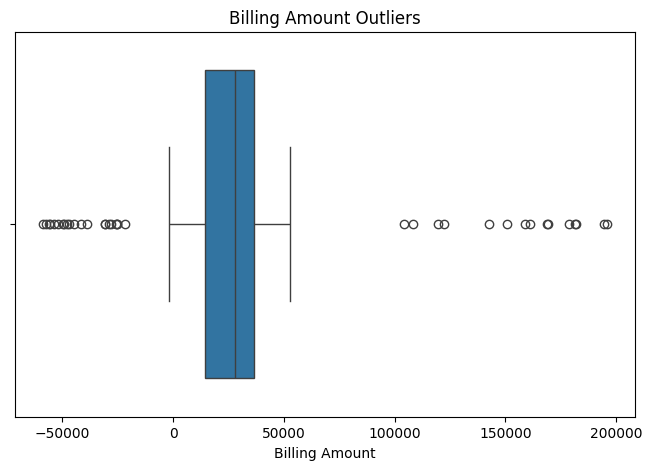

In [142]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Billing Amount'])
plt.title('Billing Amount Outliers')
plt.show()

##### Check Outlier Limits using IQR

In [143]:
Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('Lower Limit :', lower_limit)
print('Upper Limit :', upper_limit)

Lower Limit : -19319.487500000007
Upper Limit : 70311.6325


##### Find Outliers

In [144]:
outliers = df[(df['Billing Amount'] < lower_limit) | (df['Billing Amount'] > upper_limit)]
print('Total Outliers:', outliers.shape[0])

Total Outliers: 36


##### Treat Outliers: apply capping instead of removing

In [145]:
df['Billing Amount'] = np.where(df['Billing Amount'] < lower_limit, lower_limit, df['Billing Amount']) # lower capping

In [146]:
df['Billing Amount'] = np.where( df['Billing Amount'] > upper_limit, upper_limit, df['Billing Amount']) # upper capping

In [147]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55446.000000,55446,55446.000000,55446.000000,55446
mean,51.608953,2021-09-12 20:10:21.750892,26431.424933,301.151246,2021-09-05 09:48:03.973595
min,13.000000,2019-01-06 00:00:00,-19319.487500,101.000000,2019-01-06 00:00:00
25%,36.000000,2020-04-03 00:00:00,14292.182500,210.000000,2020-04-20 00:00:00
50%,52.000000,2021-08-07 00:00:00,27737.420000,302.000000,2021-08-25 00:00:00
75%,67.000000,2022-12-25 00:00:00,36699.962500,392.000000,2023-01-09 00:00:00
max,89.000000,2024-12-04 00:00:00,70311.632500,500.000000,2024-12-05 00:00:00
std,18.791821,NaN,14002.112892,110.534060,NaN


##### Why Use Outlier Capping? - In healthcare data: high bills can be real and by removing rows may lose important business information, So capping is safer

### Feature Engineering

##### Create Length of Stay

In [164]:
df['Length of Stay'] = ((df['Discharge Date'] - df['Date of Admission']).abs()).dt.days # create hospital stay duration

##### Why Create Length of Stay? - Hospitals use this KPI to: analyze patient occupancy, estimate room usage, improve operational planning

##### Create Admission Month

In [149]:
df['Admission Month'] = df['Date of Admission'].dt.month_name() # extract month

##### Create Age Group

In [150]:
bins = [0,18,35,50,65,100]
labels = ['Child','Young Adult','Adult','Senior Adult','Old Age']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

##### Why Feature Engineering? - Feature engineering creates: deeper insights, better storytelling, business-focused KPIs

In [165]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Admission Month,Age Group
0,Aaron Craig,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2,January,Young Adult
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Unknown,6,August,Senior Adult
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Michael Smith,Cook PLC,Aetna,27955.10,205,Emergency,2022-07-10,Aspirin,Normal,74,September,Old Age
3,Aaron Craig,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,November,Young Adult
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,LLC Smith,Blue Cross,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20,September,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.71,417,Elective,2020-09-15,Penicillin,Abnormal,30,August,Adult
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.80,316,Elective,2020-01-02,Lipitor,Normal,21,January,Senior Adult
55497,Heather Wang,38,Female,B+,Diabetes,2020-07-13,Joe Jacobs DVM,and Mahoney Johnson Vasquez,UnitedHealthcare,27620.76,347,Urgent,2020-10-08,Ibuprofen,Abnormal,87,July,Adult
55498,Jennifer Jones,43,Male,O-,Arthritis,2020-03-04,Kimberly Curry,Jackson Todd and Castro,Medicare,32451.09,321,Elective,2019-05-31,Ibuprofen,Abnormal,278,March,Adult


### Exploratory Data Analysis (EDA)

### Univariate Analysis

##### Age Distribution

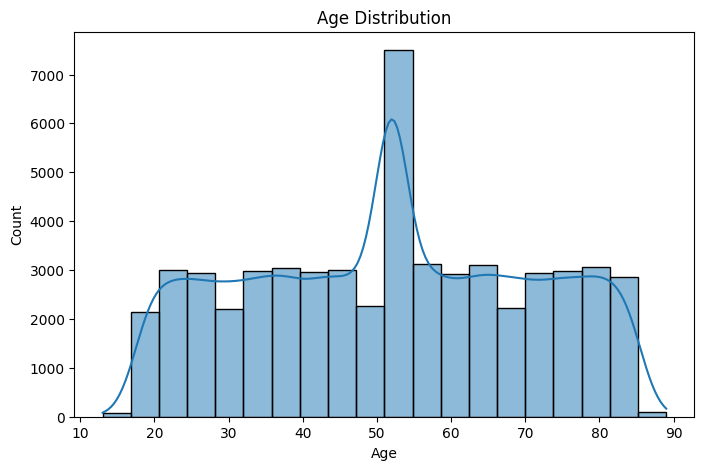

In [151]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

##### Insight: Most patients belong to middle-age and senior-age groups

##### Medical Condition Count

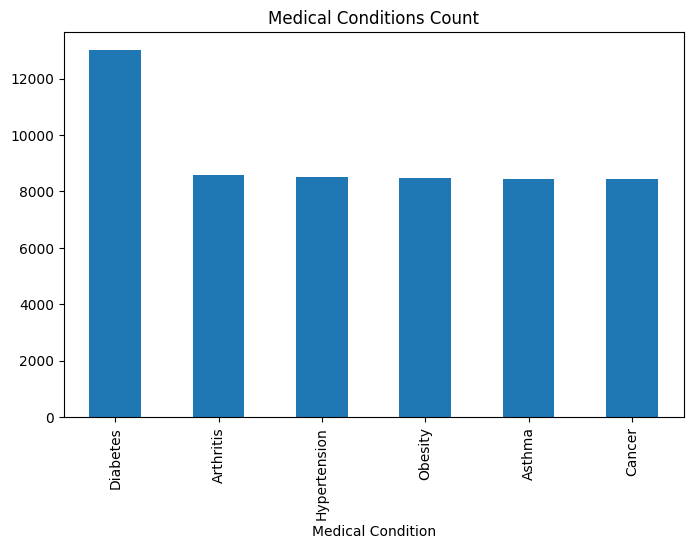

In [152]:
plt.figure(figsize=(8,5))
df['Medical Condition'].value_counts().plot(kind='bar')
plt.title('Medical Conditions Count')
plt.show()

##### Insight: Arthritis is most common diseases handled by the hospital

##### Admission Type Analysis

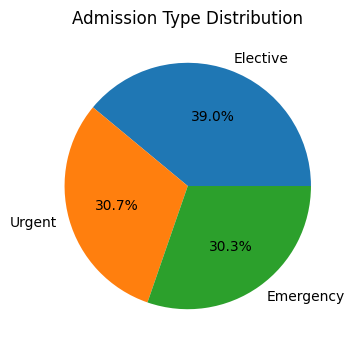

In [153]:
plt.figure(figsize=(6,4))
df['Admission Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Admission Type Distribution')
plt.ylabel('')
plt.show()

### Bivariate Analysis

##### Billing Amount by Admission Type

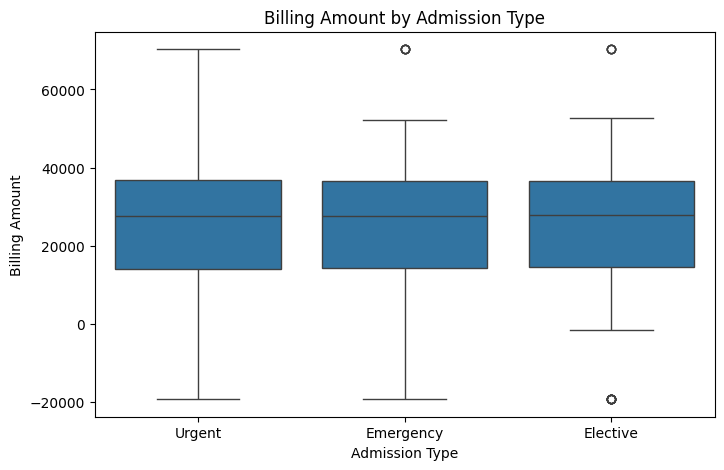

In [154]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
plt.title('Billing Amount by Admission Type')
plt.show()

##### Gender vs Medical Condition

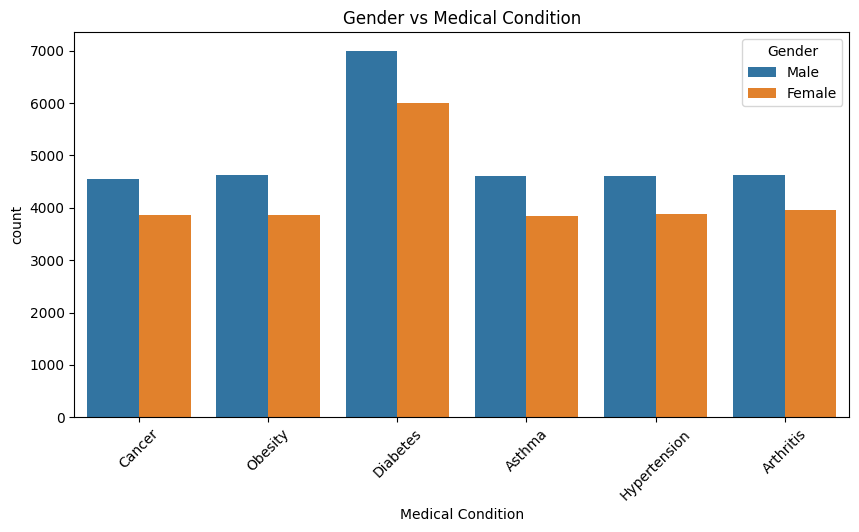

In [155]:
plt.figure(figsize=(10,5))
sns.countplot(x='Medical Condition', hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title('Gender vs Medical Condition')
plt.show()

##### Age Group vs Admission Type

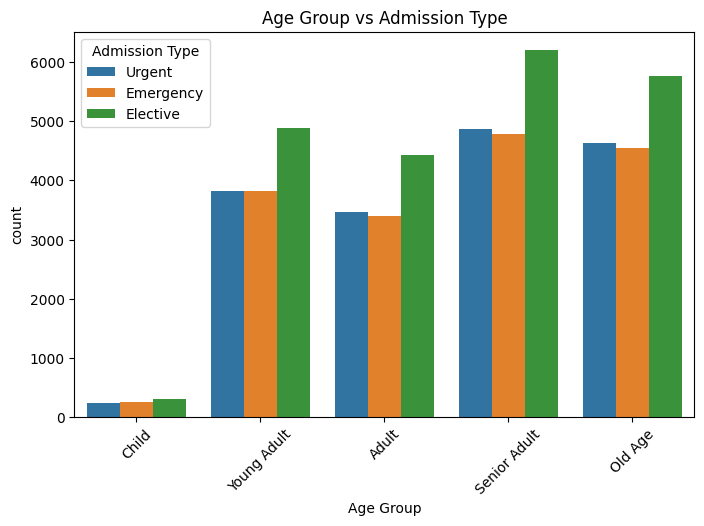

In [156]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age Group', hue='Admission Type', data=df)
plt.title('Age Group vs Admission Type')
plt.xticks(rotation=45)
plt.show()

##### Monthly Admission Trend

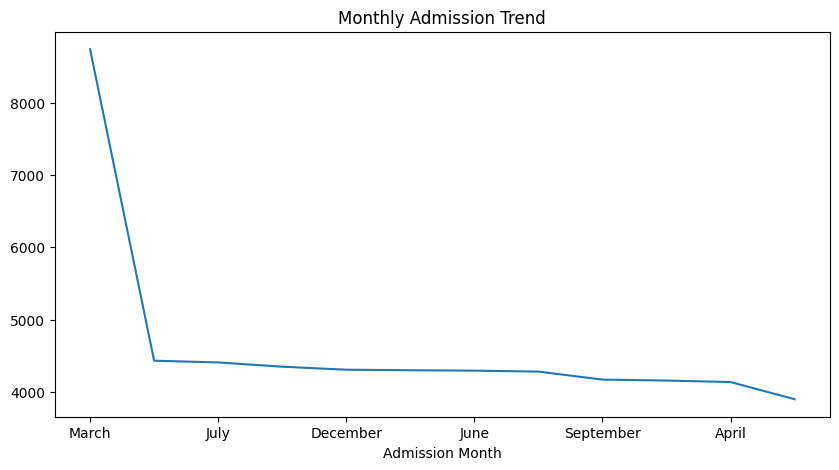

In [158]:
monthly_admission = (df.groupby('Admission Month').size().sort_values(ascending=False))
plt.figure(figsize=(10,5))
monthly_admission.plot(kind='line')
plt.title('Monthly Admission Trend')
plt.show()

##### Top Insurance Providers

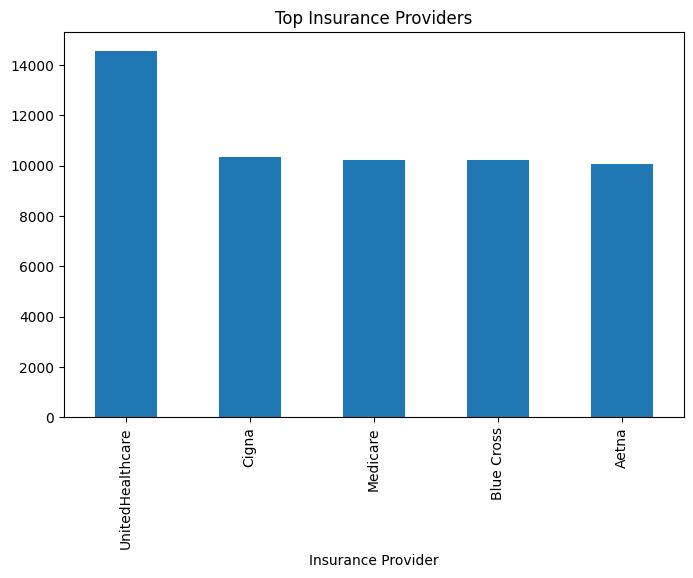

In [159]:
plt.figure(figsize=(8,5))
df['Insurance Provider'].value_counts().plot(kind='bar')
plt.title('Top Insurance Providers')
plt.show()

##### Average Billing Amount by Medical Condition

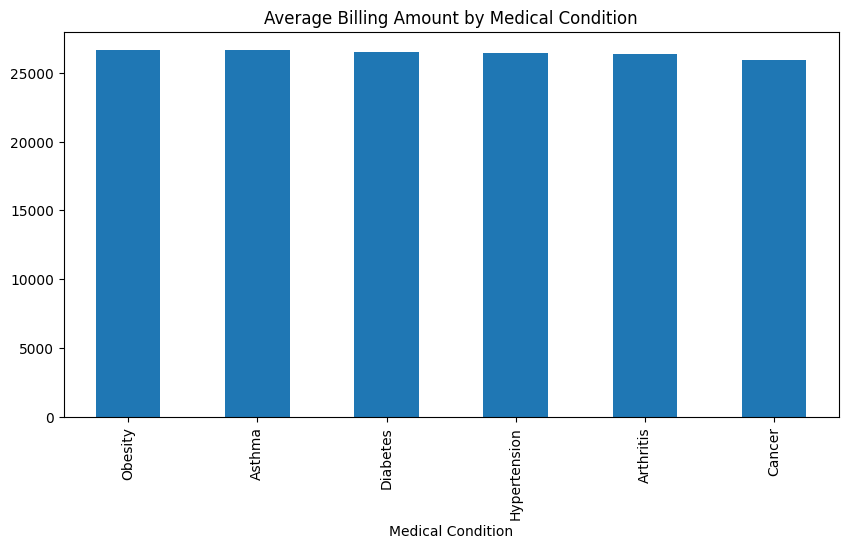

In [160]:
avg_bill = (df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,5))
avg_bill.plot(kind='bar')
plt.title('Average Billing Amount by Medical Condition')
plt.show()

### Multivariate Analysis

##### Correlation Heatmap

In [161]:
numerical_cols = df.select_dtypes(include=np.number)

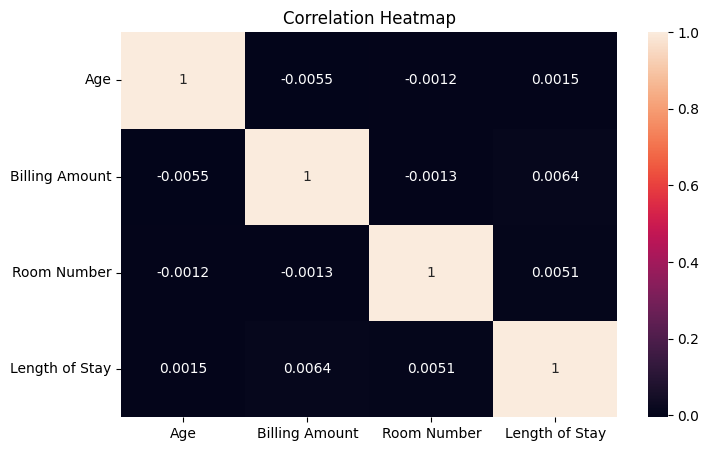

In [162]:
plt.figure(figsize=(8,5))
sns.heatmap(numerical_cols.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

##### Why Correlation? - Correlation helps identify: relationships between variables, positive/negative impact, hidden business patterns

In [166]:
pd.crosstab(index=[df['Gender'], df['Age Group']], columns=df['Medical Condition'])

Medical Condition    Arthritis  Asthma  Cancer  Diabetes  Hypertension  \
Gender Age Group                                                         
Female Child                59      55      58        88            57   
       Young Adult         894     900     865      1384           853   
       Adult               812     757     788      1235           806   
       Senior Adult       1094    1072    1127      1664          1078   
       Old Age            1098    1066    1027      1628          1097   
Male   Child                68      66      68        87            60   
       Young Adult        1015    1049    1025      1594          1024   
       Adult               948     936     910      1447           927   
       Senior Adult       1343    1302    1286      2028          1395   
       Old Age            1253    1247    1269      1848          1201   

Medical Condition    Obesity  
Gender Age Group              
Female Child              57  
       Young Adult       879  
       Adult             780  
       Senior Adult     1139  
       Old Age          1015  
Male   Child              74  
       Young Adult      1050  
       Adult             940  
       Senior Adult     1340  
       Old Age          1214

##### Business Recommendations:
##### Focus on High-Risk Age Groups - Senior patients require preventive programs and regular health monitoring
##### Improve Billing Monitoring - high-cost treatments, abnormal billing spikes, emergency service costs